In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/processed/train_processed.csv"

df = pd.read_csv(DATA_PATH,dtype={"StateHoliday": "string"})

df["Date"] = pd.to_datetime(df["Date"])

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Unique stores:", df["Store"].nunique())

Shape: (1017209, 18)
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Unique stores: 1115


##### 1. Understand the dataset

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  string        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [116]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Store,1017209.0,NaN,NaN,NaN,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,NaN,NaN,NaN,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,NaN,NaN,NaN,2014-04-11 01:30:42.846061824,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,NaN,NaN,NaN,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,NaN,NaN,NaN,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,NaN,NaN,NaN,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,NaN,NaN,NaN,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
StateHoliday,1017209,4,0,986159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SchoolHoliday,1017209.0,NaN,NaN,NaN,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056
StoreType,1017209,4,a,551627,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### 2. Check missing values

In [117]:
missing = df.isna().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Promo2SinceYear              508031
Promo2SinceWeek              508031
PromoInterval                508031
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
CompetitionDistance            2642
dtype: int64


##### 3. Check Sales

In [118]:
print("Minimum Sales:", df["Sales"].min())
print("Maximum Sales:", df["Sales"].max())
print("Average Sales:", df["Sales"].mean())
print("Median Sales:", df["Sales"].median())

Minimum Sales: 0
Maximum Sales: 41551
Average Sales: 5773.818972305593
Median Sales: 5744.0


##### 4. Check Customers

In [119]:
print("Minimum Customers:", df["Customers"].min())
print("Maximum Customers:", df["Customers"].max())
print("Average Customers:", df["Customers"].mean())

Minimum Customers: 0
Maximum Customers: 7388
Average Customers: 633.1459464082602


##### 5. Sales distribution

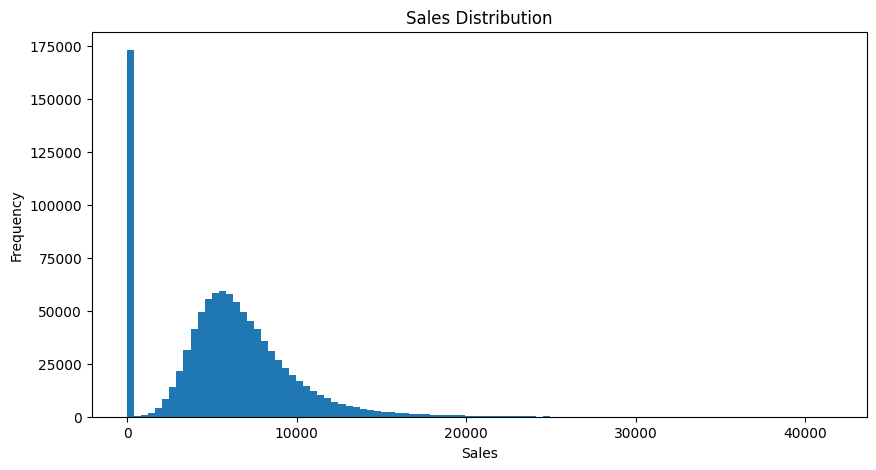

In [120]:
plt.figure(figsize=(10, 5))

plt.hist(df["Sales"], bins=100)

plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")

plt.show()

##### 6. Sales over time

In [121]:
daily_sales = (
    df.groupby("Date")["Sales"]
      .sum()
      .reset_index()
)

print(daily_sales)

          Date     Sales
0   2013-01-01     97235
1   2013-01-02   6949829
2   2013-01-03   6347820
3   2013-01-04   6638954
4   2013-01-05   5951593
..         ...       ...
937 2015-07-27  10707292
938 2015-07-28   9115073
939 2015-07-29   8499962
940 2015-07-30   8798854
941 2015-07-31  10109742

[942 rows x 2 columns]


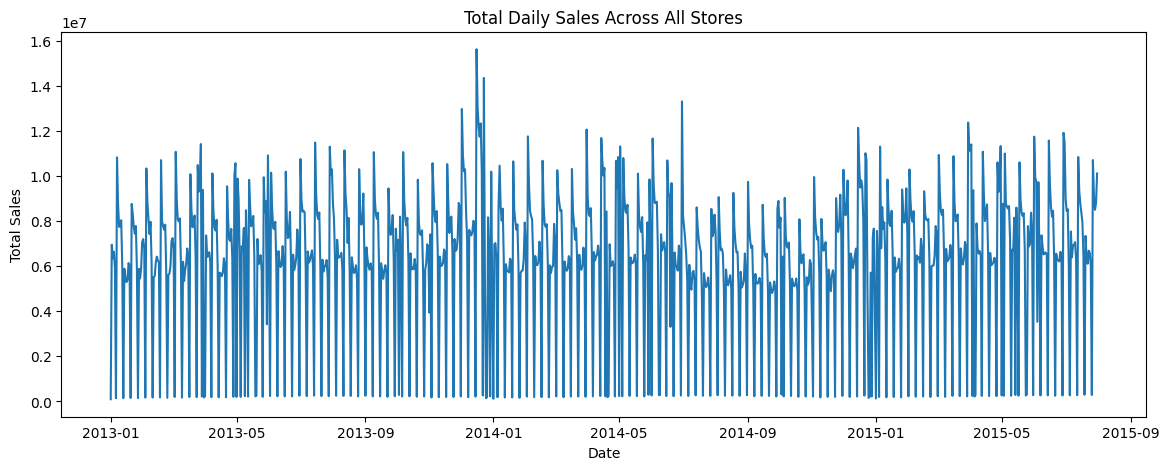

In [122]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"]
)

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Total Daily Sales Across All Stores")

plt.show()

##### 7. Sales by day of week

In [123]:
dow_sales = (
    df.groupby("DayOfWeek")["Sales"]
      .mean()
      .reset_index()
)

print(dow_sales)

   DayOfWeek        Sales
0          1  7809.044510
1          2  7005.244467
2          3  6555.884138
3          4  6247.575913
4          5  6723.274305
5          6  5847.562599
6          7   204.183189


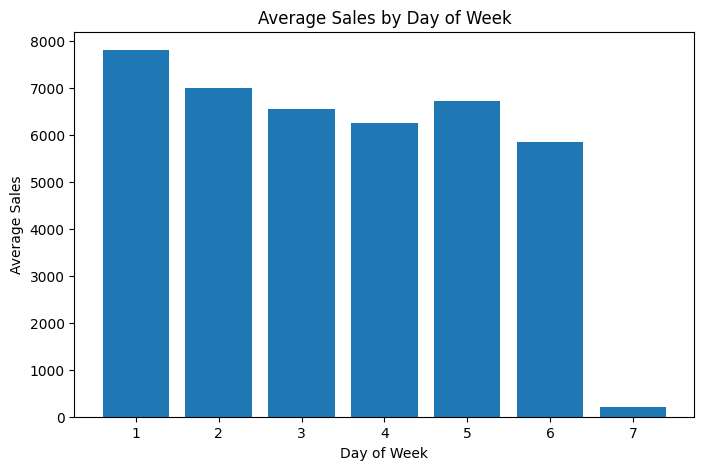

In [124]:
plt.figure(figsize=(8, 5))

plt.bar(
    dow_sales["DayOfWeek"],
    dow_sales["Sales"]
)

plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.title("Average Sales by Day of Week")

plt.show()

##### 8. Promotion impact

In [125]:
promo_sales = (
    df.groupby("Promo")["Sales"]
      .agg(["mean", "median", "count"])
)

print(promo_sales)

              mean  median   count
Promo                             
0      4406.050805  4622.0  629129
1      7991.152046  7553.0  388080


##### 9. Store type

In [126]:
store_type_sales = (
    df.groupby("StoreType")["Sales"]
      .agg(["mean", "median", "count"])
)

print(store_type_sales)

                   mean  median   count
StoreType                              
a           5738.179710  5618.0  551627
b          10058.837334  9025.5   15830
c           5723.629246  5766.0  136840
d           5641.819243  5826.0  312912


# Initial EDA Findings

## Dataset

- Total observations: (1017209, 18)
- Number of stores: 1115
- Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00

## Sales

- Average sales: 5773.818972305593
- Median sales: 5744.0
- Minimum sales: 0
- Maximum sales: 41551

## Key Observations

1. The dataset contains 1,017,209 daily store-level observations covering
   1,115 stores from January 2013 to July 2015, providing a strong historical
   foundation for sales forecasting.

2. Sales show substantial variation, ranging from 0 to 41,551, indicating
   significant differences in sales performance across stores and dates.

3. The mean sales of approximately 5,774 is close to the median of 5,744,
   suggesting that overall sales are relatively balanced, although extreme
   values are present.

4. There are 172,871 zero-sales records. Of these, 172,817 (99.97%) occurred
   when the store was closed (`Open = 0`). Therefore, most zero-sales records
   represent store closures rather than zero customer demand.

5. Only 54 records have zero sales while the store is open. These records
   require further investigation during data-quality and outlier analysis.

##### “Are zero Sales records associated with Open = 0?”

In [127]:
zero_sales = df[df["Sales"] == 0]

print("Zero-sales records:", len(zero_sales))

print(
    zero_sales["Open"].value_counts()
)

Zero-sales records: 172871
Open
0    172817
1        54
Name: count, dtype: int64


In [128]:
print(
    pd.crosstab(
        df["Open"],
        df["Sales"] == 0
    )
)

Sales   False   True 
Open                 
0           0  172817
1      844338      54


##### What business factors appear to influence Rossmann sales?

##### 10B.1 — Promotion Impact

In [129]:
promo_analysis = (
    df.groupby("Promo")["Sales"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

print(promo_analysis)

   Promo         mean  median   count
0      0  4406.050805  4622.0  629129
1      1  7991.152046  7553.0  388080


In [130]:
promo_mean = promo_analysis.set_index("Promo")["mean"]

promo_difference = (
    (promo_mean[1] - promo_mean[0])
    / promo_mean[0]
) * 100

print(f"Average sales difference with promotion: {promo_difference:.2f}%")

Average sales difference with promotion: 81.37%


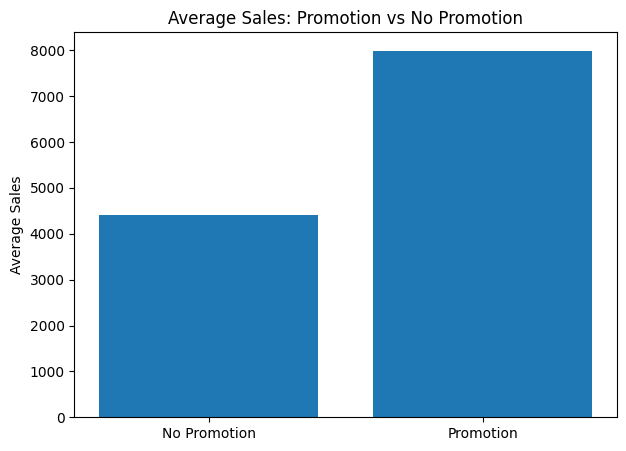

In [131]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["No Promotion", "Promotion"],
    promo_mean.values
)

plt.ylabel("Average Sales")
plt.title("Average Sales: Promotion vs No Promotion")

plt.show()

## Promotion Impact

### Observation

Stores recorded significantly higher average sales on promotional days.

- Average sales without promotion: 4,406
- Average sales with promotion: 7,991
- Average sales increase: 81.37%

The median sales also increased from 4,622 on non-promotion days
to 7,553 on promotion days.

### Business Relevance

Promotion is a strong potential driver of store sales and should be
included as an important feature in the forecasting model.

However, this analysis shows association rather than causation.
Other factors such as day of week, store characteristics and holidays
may also contribute to the observed difference.

##### 10B.2 — Day-of-Week Analysis

In [132]:
dow_analysis = (
    df.groupby("DayOfWeek")["Sales"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

print(dow_analysis)

   DayOfWeek         mean  median   count
0          1  7809.044510  7310.0  144730
1          2  7005.244467  6463.0  145664
2          3  6555.884138  6133.0  145665
3          4  6247.575913  6020.0  145845
4          5  6723.274305  6434.0  145845
5          6  5847.562599  5410.0  144730
6          7   204.183189     0.0  144730


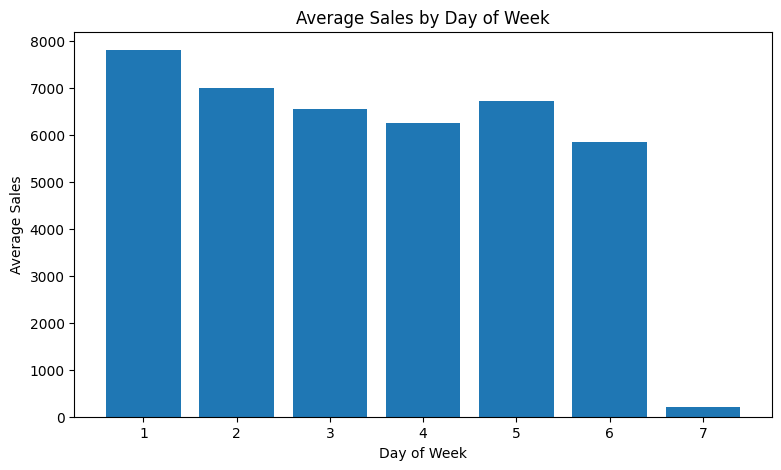

In [133]:
plt.figure(figsize=(9, 5))

plt.bar(
    dow_analysis["DayOfWeek"],
    dow_analysis["mean"]
)

plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.title("Average Sales by Day of Week")

plt.show()

##### verify the relationship between DayOfWeek and Open.

In [134]:
open_by_day = (
    df.groupby("DayOfWeek")["Open"]
      .agg(["mean", "sum", "count"])
      .reset_index()
)

print(open_by_day)

   DayOfWeek      mean     sum   count
0          1  0.950459  137560  144730
1          2  0.988309  143961  145664
2          3  0.974400  141936  145665
3          4  0.923199  134644  145845
4          5  0.950598  138640  145845
5          6  0.995357  144058  144730
6          7  0.024826    3593  144730


In [135]:
sales_open_day = (
    df.groupby(["DayOfWeek", "Open"])["Sales"]
      .mean()
      .reset_index()
)

print(sales_open_day)

    DayOfWeek  Open        Sales
0           1     0     0.000000
1           1     1  8216.073074
2           2     0     0.000000
3           2     1  7088.113656
4           3     0     0.000000
5           3     1  6728.122978
6           4     0     0.000000
7           4     1  6767.310159
8           5     0     0.000000
9           5     1  7072.677012
10          6     0     0.000000
11          6     1  5874.840238
12          7     0     0.000000
13          7     1  8224.723908


## Day-of-Week Impact

### Observation

1. Store opening behavior varies significantly by day of the week.

2. Sunday has an extremely low average Open rate of only 2.48%, while
   Saturday has the highest Open rate at approximately 99.54%.

3. The overall Sunday average sales of approximately 204 is therefore
   largely explained by store closures.

4. When stores are open, Sunday has an average sales value of approximately
   8,225, which is actually higher than the open-store averages for most
   other days.

5. Therefore, `Open` status is a critical variable when interpreting the
   relationship between DayOfWeek and Sales.

### Business Relevance

DayOfWeek and Open status should both be included in the forecasting
features. Using DayOfWeek alone could incorrectly suggest that Sunday
has inherently poor sales performance.

##### 10B.3 — Holiday Impact

In [136]:
state_holiday_analysis = (
    df.groupby("StateHoliday")["Sales"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

print(state_holiday_analysis)

  StateHoliday         mean  median   count
0            0  5947.483893  5849.0  986159
1            a   290.735686     0.0   20260
2            b   214.311510     0.0    6690
3            c   168.733171     0.0    4100


In [137]:
school_holiday_analysis = (
    df.groupby("SchoolHoliday")["Sales"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

print(school_holiday_analysis)

   SchoolHoliday         mean  median   count
0              0  5620.979034  5642.0  835488
1              1  6476.522207  6197.0  181721


In [138]:
print(df["StateHoliday"].unique())
print(df["StateHoliday"].value_counts(dropna=False))

<StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: string
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: Int64


In [139]:
print(df["StateHoliday"].apply(lambda x: (x, type(x).__name__)).value_counts())

StateHoliday
(0, str)    986159
(a, str)     20260
(b, str)      6690
(c, str)      4100
Name: count, dtype: int64


In [140]:
state_holiday_analysis = (
    df.groupby("StateHoliday")["Sales"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

print(state_holiday_analysis)

  StateHoliday         mean  median   count
0            0  5947.483893  5849.0  986159
1            a   290.735686     0.0   20260
2            b   214.311510     0.0    6690
3            c   168.733171     0.0    4100


### State Holiday Observation

Sales are substantially lower on StateHoliday days than on normal days.

- Normal days: approximately 5,947 average sales
- Holiday type `a`: approximately 291 average sales
- Holiday type `b`: approximately 214 average sales
- Holiday type `c`: approximately 169 average sales

The extremely low sales values on StateHoliday days are likely associated
with store closures or reduced store operations. Therefore, StateHoliday
should be considered together with the Open variable when building the
forecasting model.

StateHoliday is a potentially important feature for predicting store sales.

##### 10B.4 — Store Characteristics

##### 1. Store Type

In [141]:
store_type_analysis = (
    df.groupby("StoreType")["Sales"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

print(store_type_analysis)

  StoreType          mean  median   count
0         a   5738.179710  5618.0  551627
1         b  10058.837334  9025.5   15830
2         c   5723.629246  5766.0  136840
3         d   5641.819243  5826.0  312912


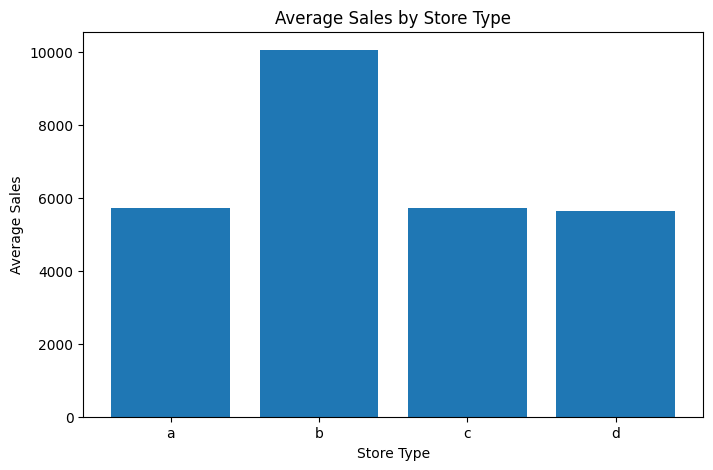

In [142]:
plt.figure(figsize=(8, 5))

plt.bar(
    store_type_analysis["StoreType"],
    store_type_analysis["mean"]
)

plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.title("Average Sales by Store Type")

plt.show()

##### 2. Assortment

In [143]:
assortment_analysis = (
    df.groupby("Assortment")["Sales"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

print(assortment_analysis)

  Assortment         mean  median   count
0          a  5481.026096  5463.0  537445
1          b  8553.931999  8026.5    8294
2          c  6058.676567  6039.0  471470


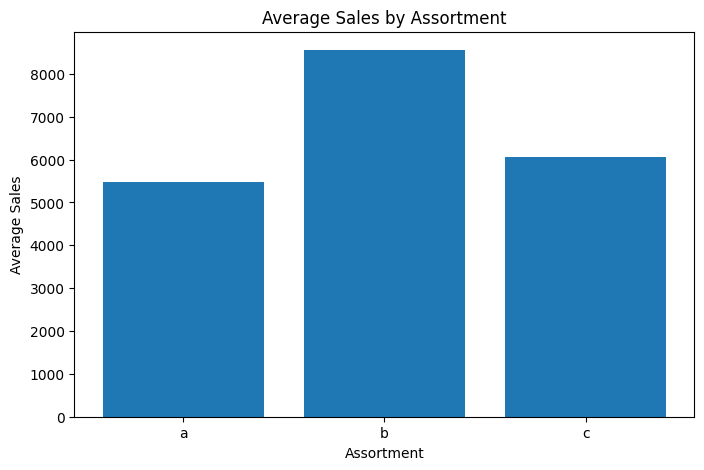

In [144]:
plt.figure(figsize=(8, 5))

plt.bar(
    assortment_analysis["Assortment"],
    assortment_analysis["mean"]
)

plt.xlabel("Assortment")
plt.ylabel("Average Sales")
plt.title("Average Sales by Assortment")

plt.show()

##### 3. Competition Distance

In [145]:
print(
    df["CompetitionDistance"].isna().sum()
)

2642


In [146]:
print(
    df["CompetitionDistance"].describe()
)

count    1.014567e+06
mean     5.430086e+03
std      7.715324e+03
min      2.000000e+01
25%      7.100000e+02
50%      2.330000e+03
75%      6.890000e+03
max      7.586000e+04
Name: CompetitionDistance, dtype: float64


In [147]:
df["CompetitionDistanceBand"] = pd.cut(
    df["CompetitionDistance"],
    bins=[0, 1000, 2500, 5000, 10000, float("inf")],
    labels=[
        "0-1km",
        "1-2.5km",
        "2.5-5km",
        "5-10km",
        "10km+"
    ]
)

In [148]:
competition_analysis = (
    df.groupby(
        "CompetitionDistanceBand",
        observed=True
    )["Sales"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

print(competition_analysis)

  CompetitionDistanceBand         mean  median   count
0                   0-1km  6063.365791  5822.0  302211
1                 1-2.5km  5715.756212  5618.0  222554
2                 2.5-5km  5623.084127  5746.0  170980
3                  5-10km  5567.718124  5780.0  147636
4                   10km+  5685.546657  5775.0  171186


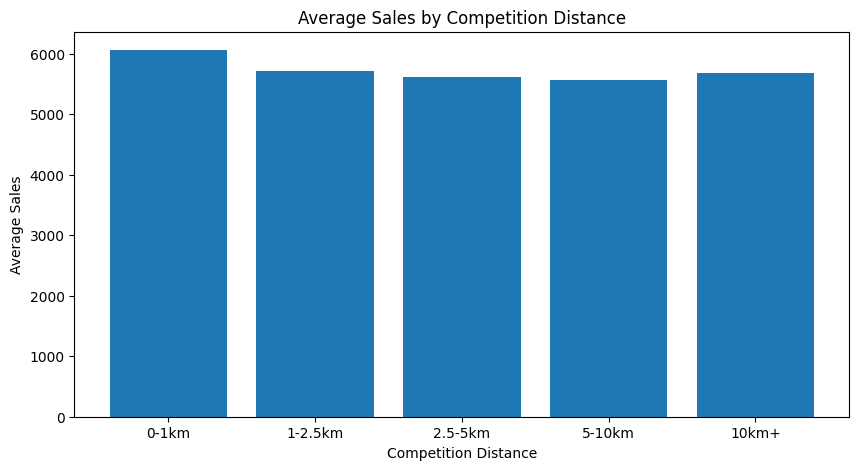

In [149]:
plt.figure(figsize=(10, 5))

plt.bar(
    competition_analysis["CompetitionDistanceBand"].astype(str),
    competition_analysis["mean"]
)

plt.xlabel("Competition Distance")
plt.ylabel("Average Sales")
plt.title("Average Sales by Competition Distance")

plt.show()

## 10B.4 — Store Characteristics

### Store Type

Store type shows substantial differences in average sales.

- Type B: approximately 10,059
- Type A: approximately 5,738
- Type C: approximately 5,724
- Type D: approximately 5,642

Type B has considerably higher average sales than the other store types.
However, Type B has only 15,830 observations, so this result should be
interpreted carefully.

### Assortment

Assortment is also associated with differences in sales.

- Assortment B: approximately 8,554
- Assortment C: approximately 6,059
- Assortment A: approximately 5,481

Assortment B has the highest average sales, although it has a relatively
small number of observations.

### Competition Distance

CompetitionDistance has 2,642 missing values.

For the available values:

- Mean: approximately 5,430
- Median: 2,330
- Minimum: 20
- Maximum: 75,860

Stores within 1 km of a competitor have the highest average sales
(approximately 6,063), while stores 5–10 km away have approximately
5,568 average sales.

There is no clear linear relationship between competition distance and
sales based on this analysis alone.

### Business Relevance

StoreType and Assortment appear to be important potential predictors of
sales.

CompetitionDistance may also provide useful information, but its
relationship with sales is not straightforward. The missing values require
a separate treatment decision during feature engineering.

##### 10B.5 — Sales vs Customers

In [150]:
customer_sales = df[
    (df["Open"] == 1) &
    (df["Sales"] > 0)
]

print(customer_sales[["Customers", "Sales"]].describe())

           Customers          Sales
count  844338.000000  844338.000000
mean      762.777166    6955.959134
std       401.194153    3103.815515
min         8.000000      46.000000
25%       519.000000    4859.000000
50%       676.000000    6369.000000
75%       893.000000    8360.000000
max      7388.000000   41551.000000


In [153]:
print(
    customer_sales[["Customers", "Sales"]].corr()
)

           Customers     Sales
Customers   1.000000  0.823552
Sales       0.823552  1.000000


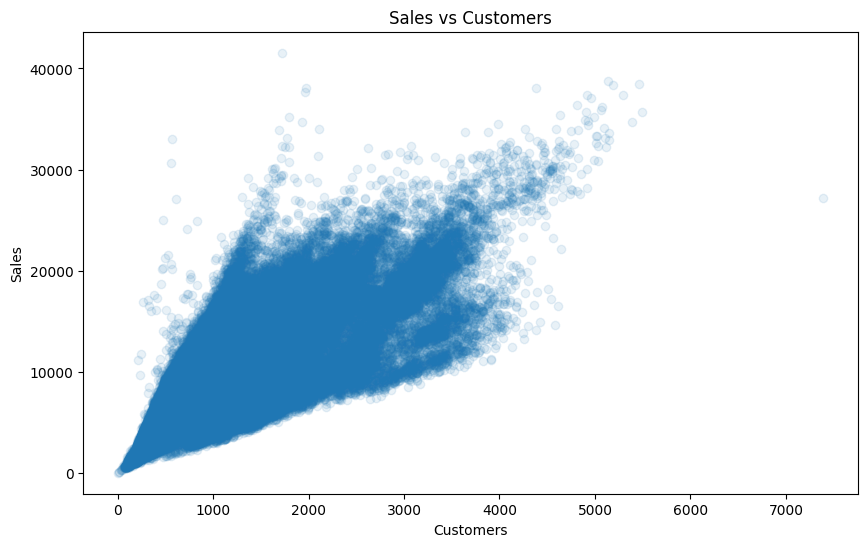

In [152]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_sales["Customers"],
    customer_sales["Sales"],
    alpha=0.1
)

plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Sales vs Customers")

plt.show()

##### ## 10B.5 — Sales vs Customers

### Observation

There is a strong positive correlation between Customers and Sales, with a
correlation coefficient of approximately 0.824.

Among open stores with positive sales:

- Average customers: approximately 763
- Average sales: approximately 6,956
- Maximum customers: 7,388
- Maximum sales: 41,551

The strong positive relationship indicates that customer volume is closely
associated with store sales.

### Business Relevance

Customers is a strong potential predictor of Sales. However, its availability
at prediction time must be considered carefully before using it as a model
feature. If future customer counts are not known when the forecast is
generated, using Customers could result in data leakage.

Therefore, Customers should be evaluated separately during feature engineering
and model design.

##### 10C.1 — High Sales Analysis

In [154]:
# Top 1% sales threshold
sales_99 = df["Sales"].quantile(0.99)

print("99th percentile:", sales_99)

high_sales = df[df["Sales"] > sales_99]

print("High-sales records:", len(high_sales))
print(high_sales["Sales"].describe())

99th percentile: 17160.0
High-sales records: 10172
count    10172.000000
mean     20238.517892
std       2969.224179
min      17161.000000
25%      18124.750000
50%      19352.000000
75%      21387.000000
max      41551.000000
Name: Sales, dtype: float64


##### 10C.2 — Inspect the highest sales records

In [155]:
top_sales = df.nlargest(
    20,
    "Sales"
)

print(
    top_sales[
        [
            "Store",
            "Date",
            "Sales",
            "Customers",
            "Open",
            "Promo",
            "StateHoliday",
            "SchoolHoliday",
            "StoreType",
            "Assortment"
        ]
    ]
)

        Store       Date  Sales  Customers  Open  Promo StateHoliday  \
44393     909 2015-06-22  41551       1721     1      0            0   
132946    262 2015-04-03  38722       5132     1      1            b   
101726    262 2015-05-01  38484       5458     1      1            a   
87231     262 2015-05-14  38367       5192     1      0            a   
424086     57 2014-06-16  38037       1970     1      1            0   
627776    817 2013-12-16  38025       4381     1      1            0   
627220    261 2013-12-16  37646       1964     1      1            0   
444361    262 2014-05-29  37403       5297     1      0            a   
620531    262 2013-12-22  37376       4916     1      0            0   
245945    262 2014-12-21  37122       4962     1      0            0   
265580    262 2014-11-30  36417       4816     1      0            0   
919351    262 2013-03-29  36227       5069     1      1            b   
490076    262 2014-04-18  35909       5063     1      1         

##### 10C.3 — Check whether extreme sales are valid

In [156]:
print(
    high_sales[
        ["Open", "Promo", "StateHoliday", "SchoolHoliday"]
    ].value_counts()
)

Open  Promo  StateHoliday  SchoolHoliday
1     1      0             0                5751
      0      0             0                2080
      1      0             1                1508
      0      0             1                 761
             a             0                  21
      1      a             0                  16
             b             1                  11
      0      a             1                   8
             c             1                   5
             b             1                   4
                           0                   3
      1      b             0                   3
             a             1                   1
Name: count, dtype: int64


In [158]:
print(
    high_sales.groupby("StoreType")["Sales"]
    .agg(["mean", "median", "count"])
)

                   mean   median  count
StoreType                              
a          20265.093740  19385.0   6550
b          20612.448215  19540.0   1709
c          19649.889632  18925.0    897
d          19957.888780  19186.5   1016


## 10C — Outlier Analysis

### High Sales Analysis

The 99th percentile of Sales is 17,160, resulting in 10,172 observations
above this threshold.

The maximum recorded sales value is 41,551.

### Observations

1. High-sales records occur only when stores are open (`Open = 1`), which
   supports their validity.

2. High-sales observations occur under both promotional and
   non-promotional conditions, indicating that promotion alone does not
   explain extreme sales.

3. High-sales observations occur across all StoreTypes, suggesting that
   extreme sales are not limited to a single store type.

4. Some high-sales records have large customer counts, supporting the
   relationship between customer volume and sales.

5. The highest sales values should not be automatically removed or capped
   because they may represent genuine high-demand business situations.

### Decision

High Sales values will be retained in the dataset.

No outlier removal or arbitrary capping will be performed at this stage.
Potential extreme observations will be handled through appropriate model
and feature-engineering techniques if required.

In [159]:
holiday_high_sales = df[
    (df["Sales"] > sales_99) &
    (df["StateHoliday"].astype(str) != "0")
]

print(holiday_high_sales[
    [
        "Store",
        "Date",
        "Sales",
        "Customers",
        "Open",
        "Promo",
        "StateHoliday"
    ]
].sort_values("Sales", ascending=False).head(20))

        Store       Date  Sales  Customers  Open  Promo StateHoliday
132946    262 2015-04-03  38722       5132     1      1            b
101726    262 2015-05-01  38484       5458     1      1            a
87231     262 2015-05-14  38367       5192     1      0            a
444361    262 2014-05-29  37403       5297     1      0            a
919351    262 2013-03-29  36227       5069     1      1            b
490076    262 2014-04-18  35909       5063     1      1            b
319810    262 2014-10-03  35702       5494     1      1            a
74966     262 2015-05-25  35159       4989     1      0            a
475581    262 2014-05-01  34814       4931     1      1            a
432096    262 2014-06-09  34692       5387     1      0            a
709731    262 2013-10-03  34369       4925     1      0            a
873636    262 2013-05-09  34133       5090     1      0            a
129601    262 2015-04-06  33655       5152     1      0            b
916006    262 2013-04-01  33326   

In [160]:
print(
    holiday_high_sales.groupby("StateHoliday")["Sales"]
    .agg(["count", "mean", "max"])
)

              count          mean    max
StateHoliday                            
a                46  23276.739130  38484
b                21  23557.952381  38722
c                 5  25913.400000  32169


### Holiday-Related High Sales

A small number of high-sales observations occur on StateHoliday days.

- Holiday `a`: 46 high-sales observations
- Holiday `b`: 21 high-sales observations
- Holiday `c`: 5 high-sales observations

These observations include stores that were open and had substantial customer
counts. Several of the highest values occur repeatedly for Store 262.

Therefore, these observations should not be treated as data-quality errors
without additional evidence.

### Final Outlier Decision

The high-sales observations will be retained.

No arbitrary removal, winsorization, or capping will be performed during data
cleaning. Extreme sales values will be treated as legitimate business
observations unless future validation identifies a specific data-quality issue.

# 10D — EDA Summary & Business Insights

## Dataset Overview

- 1,017,209 store-day observations
- 1,115 unique stores
- Date range: January 2013 to July 2015
- 18 columns after merging train and store data

## Key Business Insights

### 1. Promotion
Average sales were approximately 81.37% higher on promotional days than on
non-promotional days. Promotion is therefore an important potential
predictor of sales.

### 2. Weekly Seasonality
Sales vary considerably across the days of the week. However, the very low
overall Sunday sales are mainly explained by store closures. Therefore,
DayOfWeek must be interpreted together with Open status.

### 3. Store Opening Status
Open is a critical variable. Approximately 99.97% of zero-sales observations
occurred when stores were closed.

### 4. School Holidays
Average sales were approximately 15.2% higher during school holidays.
SchoolHoliday may therefore provide useful information for forecasting.

### 5. State Holidays
Sales are substantially lower on StateHoliday days. This appears to be
strongly associated with store operating status.

### 6. Store Characteristics
StoreType and Assortment show meaningful differences in average sales.
These variables should be considered as potential model features.

### 7. Competition
CompetitionDistance does not show a simple linear relationship with sales.
There are 2,642 missing values, which require appropriate treatment during
feature engineering.

### 8. Customers
Customers has a strong positive correlation with Sales of approximately
0.824. However, Customers must be evaluated carefully because future customer
counts may not be available when making a forecast.

### 9. Outliers
High-sales observations appear to be legitimate business observations.
No arbitrary removal or capping of extreme sales values will be performed.

### 10. Zero Sales
Most zero-sales observations correspond to stores being closed. Therefore,
zero-sales records should not automatically be treated as invalid data.

## Feature Engineering Implications

The EDA suggests that the forecasting model should consider:

- Store
- DayOfWeek
- Open
- Promo
- StateHoliday
- SchoolHoliday
- StoreType
- Assortment
- CompetitionDistance
- Date-derived features
- Historical sales features

Customers will require a separate decision regarding potential data leakage
and availability at prediction time.

## Final EDA Decision

The dataset contains meaningful temporal, promotional, operational, and
store-level patterns that can be used for sales forecasting.

The raw data will remain unchanged. Data cleaning and feature engineering
will continue through the automated processing pipeline.